# Telco Churn - Boosted Models Strategy

This notebook explores stronger tabular models for churn prediction and compares them against logistic regression under the same leakage-free setup.

## Goals
- Keep stratified train/validation/test splits
- Avoid preprocessing leakage
- Train CatBoost and XGBoost with light hyperparameter search
- Tune classification threshold on validation only
- Compare with deployment-relevant metrics (ROC-AUC, PR-AUC, recall, precision, F1)


In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    precision_recall_curve,
    roc_curve,
)

from catboost import CatBoostClassifier
from xgboost import XGBClassifier

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

import os
FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)


## Load, clean, encode, split

Uses the same feature cleaning approach as other notebooks, then performs a stratified 70/15/15 split.


In [2]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df = df.drop(columns=['customerID'])
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna()
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

df_encoded = pd.get_dummies(df, drop_first=True)
X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

X_tv, X_test, y_tv, y_test = train_test_split(
    X, y, test_size=0.15, random_state=SEED, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv, test_size=15 / 85, random_state=SEED, stratify=y_tv
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

print('Sizes train/val/test:', X_train.shape[0], X_val.shape[0], X_test.shape[0])
print('Churn rates train/val/test:', round(y_train.mean(), 4), round(y_val.mean(), 4), round(y_test.mean(), 4))


Sizes train/val/test: 4922 1055 1055
Churn rates train/val/test: 0.2659 0.2654 0.2654


## Utility functions


In [3]:
def threshold_max_f1(y_true, proba, n=199):
    ts = np.linspace(0.005, 0.995, n)
    best_t, best_f1 = 0.5, -1.0
    for t in ts:
        pred = (proba >= t).astype(int)
        f = f1_score(y_true, pred, zero_division=0)
        if f > best_f1:
            best_t, best_f1 = t, f
    return best_t, best_f1


def evaluate_model(name, y_val_arr, p_val, y_test_arr, p_test):
    t, val_f1 = threshold_max_f1(y_val_arr, p_val)
    y_pred = (p_test >= t).astype(int)

    return {
        'model': name,
        'threshold_from_val': t,
        'val_f1': val_f1,
        'roc_auc': roc_auc_score(y_test_arr, p_test),
        'pr_auc': average_precision_score(y_test_arr, p_test),
        'accuracy': accuracy_score(y_test_arr, y_pred),
        'precision': precision_score(y_test_arr, y_pred),
        'recall': recall_score(y_test_arr, y_pred),
        'f1': f1_score(y_test_arr, y_pred),
        'y_pred': y_pred,
        'p_test': p_test,
    }


## Logistic regression reference


In [4]:
lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=SEED)
lr.fit(X_train_s, y_train.to_numpy())
p_val_lr = lr.predict_proba(X_val_s)[:, 1]
p_test_lr = lr.predict_proba(X_test_s)[:, 1]

res_lr = evaluate_model('Logistic Regression', y_val.to_numpy(), p_val_lr, y_test.to_numpy(), p_test_lr)
res_lr


{'model': 'Logistic Regression',
 'threshold_from_val': np.float64(0.5650000000000001),
 'val_f1': 0.6463022508038585,
 'roc_auc': 0.8311797235023042,
 'pr_auc': 0.5910304247654579,
 'accuracy': 0.7469194312796209,
 'precision': 0.5160493827160494,
 'recall': 0.7464285714285714,
 'f1': 0.6102189781021898,
 'y_pred': array([1, 0, 1, ..., 0, 1, 1], shape=(1055,)),
 'p_test': array([0.8389838 , 0.01554433, 0.78363038, ..., 0.06105271, 0.86145094,
        0.86715967], shape=(1055,))}

## CatBoost search


In [5]:
cat_grid = {
    'depth': [4, 6, 8],
    'learning_rate': [0.03, 0.05, 0.1],
    'l2_leaf_reg': [3, 7],
    'iterations': [300, 500],
}

best_cat = None
best_cat_ap = -1
best_cat_params = None

for params in ParameterGrid(cat_grid):
    cat = CatBoostClassifier(
        random_seed=SEED,
        loss_function='Logloss',
        eval_metric='AUC',
        verbose=False,
        **params
    )
    cat.fit(X_train, y_train)
    p_val = cat.predict_proba(X_val)[:, 1]
    ap = average_precision_score(y_val, p_val)

    if ap > best_cat_ap:
        best_cat_ap = ap
        best_cat = cat
        best_cat_params = params

print('Best CatBoost params:', best_cat_params)
print('Best CatBoost val PR-AUC:', round(best_cat_ap, 4))

p_val_cat = best_cat.predict_proba(X_val)[:, 1]
p_test_cat = best_cat.predict_proba(X_test)[:, 1]
res_cat = evaluate_model('CatBoost', y_val.to_numpy(), p_val_cat, y_test.to_numpy(), p_test_cat)
res_cat


Best CatBoost params: {'depth': 6, 'iterations': 300, 'l2_leaf_reg': 7, 'learning_rate': 0.03}
Best CatBoost val PR-AUC: 0.6736


{'model': 'CatBoost',
 'threshold_from_val': np.float64(0.315),
 'val_f1': 0.6416938110749185,
 'roc_auc': 0.8399239631336405,
 'pr_auc': 0.6424939363340666,
 'accuracy': 0.7582938388625592,
 'precision': 0.5314861460957179,
 'recall': 0.7535714285714286,
 'f1': 0.6233382570162481,
 'y_pred': array([1, 0, 1, ..., 0, 1, 1], shape=(1055,)),
 'p_test': array([0.67128468, 0.00992239, 0.36994227, ..., 0.0577418 , 0.64290787,
        0.66119206], shape=(1055,))}

## XGBoost search


In [6]:
xgb_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.03, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'n_estimators': [300, 500],
}

pos = (y_train == 1).sum()
neg = (y_train == 0).sum()
scale_pos_weight = float(neg / pos)

best_xgb = None
best_xgb_ap = -1
best_xgb_params = None

for params in ParameterGrid(xgb_grid):
    xgb = XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=SEED,
        scale_pos_weight=scale_pos_weight,
        n_jobs=-1,
        **params
    )
    xgb.fit(X_train_s, y_train.to_numpy())
    p_val = xgb.predict_proba(X_val_s)[:, 1]
    ap = average_precision_score(y_val, p_val)

    if ap > best_xgb_ap:
        best_xgb_ap = ap
        best_xgb = xgb
        best_xgb_params = params

print('Best XGBoost params:', best_xgb_params)
print('Best XGBoost val PR-AUC:', round(best_xgb_ap, 4))

p_val_xgb = best_xgb.predict_proba(X_val_s)[:, 1]
p_test_xgb = best_xgb.predict_proba(X_test_s)[:, 1]
res_xgb = evaluate_model('XGBoost', y_val.to_numpy(), p_val_xgb, y_test.to_numpy(), p_test_xgb)
res_xgb


Best XGBoost params: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.8}
Best XGBoost val PR-AUC: 0.6642


{'model': 'XGBoost',
 'threshold_from_val': np.float64(0.36),
 'val_f1': 0.6294820717131474,
 'roc_auc': 0.8368709677419355,
 'pr_auc': 0.6389090337554832,
 'accuracy': 0.6919431279620853,
 'precision': 0.4576271186440678,
 'recall': 0.8678571428571429,
 'f1': 0.5992601726263872,
 'y_pred': array([1, 0, 1, ..., 0, 1, 1], shape=(1055,)),
 'p_test': array([0.8126232 , 0.01983   , 0.68601507, ..., 0.16958034, 0.84222597,
        0.8269354 ], shape=(1055,), dtype=float32)}

## Final comparison


In [7]:
results = [res_lr, res_cat, res_xgb]
comparison = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ['y_pred', 'p_test']} for r in results
]).sort_values(['pr_auc', 'f1'], ascending=False).reset_index(drop=True)
comparison


,model,threshold_from_val,val_f1,roc_auc,pr_auc,accuracy,precision,recall,f1
0,CatBoost,0.315,0.641694,0.839924,0.642494,0.758294,0.531486,0.753571,0.623338
1,XGBoost,0.360,0.629482,0.836871,0.638909,0.691943,0.457627,0.867857,0.599260
2,Logistic Regression,0.565,0.646302,0.831180,0.591030,0.746919,0.516049,0.746429,0.610219


In [8]:
comparison.to_csv(f"{FIG_DIR}/boosted_metrics.csv", index=False)
print(f"Saved -> {FIG_DIR}/boosted_metrics.csv")
comparison

Saved -> figures/boosted_metrics.csv


,model,threshold_from_val,val_f1,roc_auc,pr_auc,accuracy,precision,recall,f1
0,CatBoost,0.315,0.641694,0.839924,0.642494,0.758294,0.531486,0.753571,0.623338
1,XGBoost,0.360,0.629482,0.836871,0.638909,0.691943,0.457627,0.867857,0.599260
2,Logistic Regression,0.565,0.646302,0.831180,0.591030,0.746919,0.516049,0.746429,0.610219


## Confusion matrices


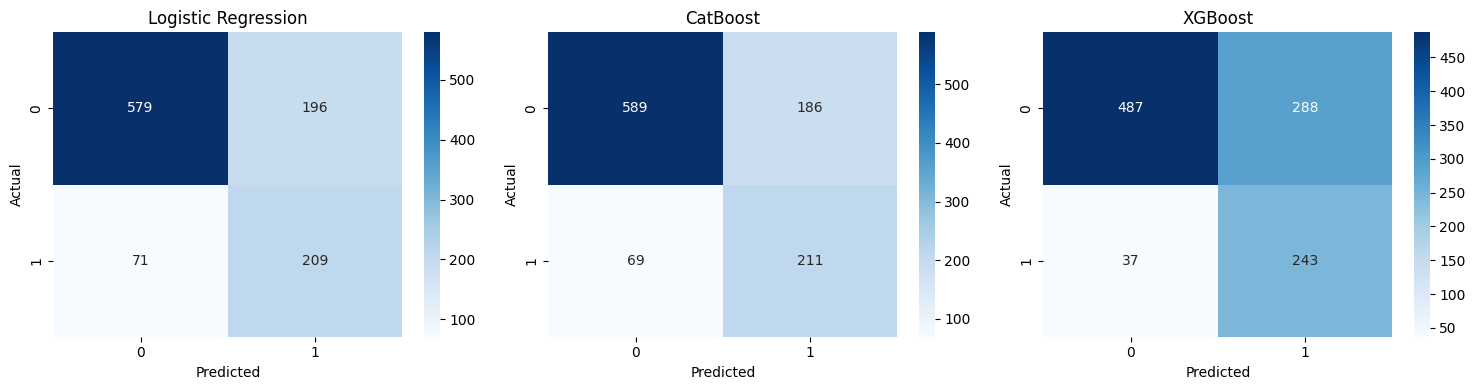

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, r in zip(axes, results):
    cm = confusion_matrix(y_test.to_numpy(), r['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(r['model'])
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/boosted_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()


## ROC and PR curves


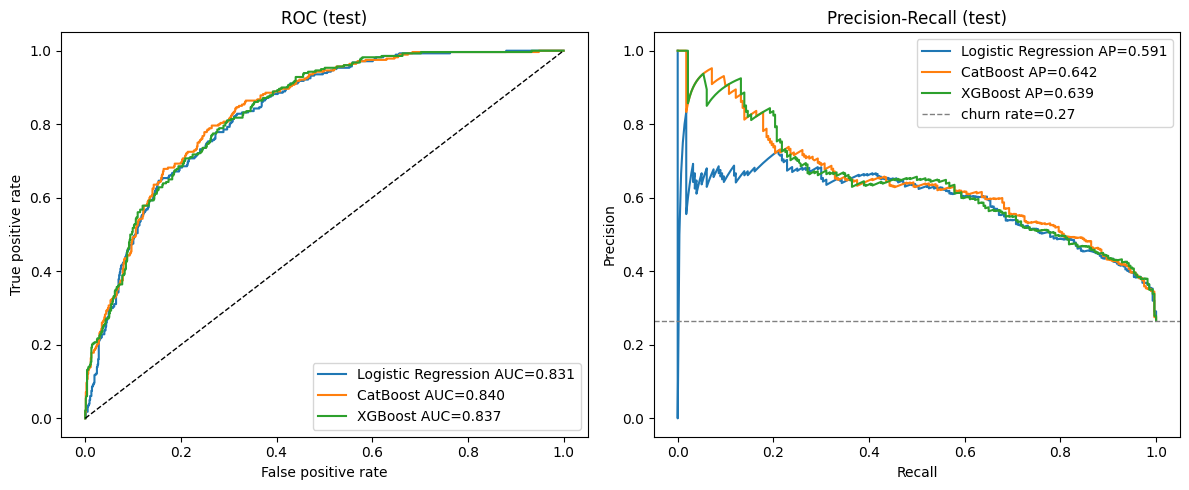

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for r in results:
    fpr, tpr, _ = roc_curve(y_test.to_numpy(), r['p_test'])
    axes[0].plot(fpr, tpr, label=f"{r['model']} AUC={r['roc_auc']:.3f}")

axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0].set_title('ROC (test)')
axes[0].set_xlabel('False positive rate')
axes[0].set_ylabel('True positive rate')
axes[0].legend()

for r in results:
    prec, rec, _ = precision_recall_curve(y_test.to_numpy(), r['p_test'])
    axes[1].plot(rec, prec, label=f"{r['model']} AP={r['pr_auc']:.3f}")

baseline = y_test.mean()
axes[1].axhline(baseline, color='gray', linestyle='--', lw=1, label=f"churn rate={baseline:.2f}")
axes[1].set_title('Precision-Recall (test)')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/boosted_roc_pr_curves.png", dpi=150, bbox_inches="tight")
plt.show()


## Interpreting outcomes

- If **PR-AUC** and recall improve with acceptable precision loss, boosted trees are helping retention targeting.
- If gains are marginal, logistic regression may remain preferable due to simpler deployment and explainability.
- Keep `scaler`, model object, and validation-tuned threshold together for reproducible inference.


In [11]:
# One-line recommendation for symposium/deployment discussion
# Set this to one of: 'f1', 'recall', 'pr_auc', 'roc_auc', 'precision', 'accuracy'
priority_metric = 'pr_auc'

best_row = comparison.sort_values(priority_metric, ascending=False).iloc[0]
print(
    f"Recommended model by {priority_metric}: {best_row['model']} "
    f"(threshold={best_row['threshold_from_val']:.3f}, "
    f"PR-AUC={best_row['pr_auc']:.3f}, Recall={best_row['recall']:.3f}, F1={best_row['f1']:.3f})"
)

Recommended model by pr_auc: CatBoost (threshold=0.315, PR-AUC=0.642, Recall=0.754, F1=0.623)


## Feature importance — which features drive churn?

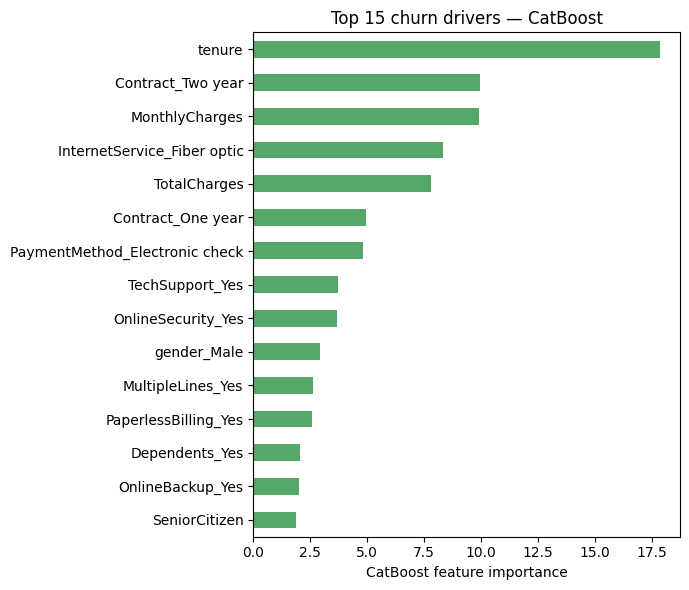

Saved -> figures/feature_importance_catboost.csv


/Users/srinidhis/NN/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/var/folders/91/9n3gj0s17g9fw3d247frrv2m0000gn/T/ipykernel_82814/72573064.py:29: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, X_val, plot_type="bar", show=False, max_display=15)


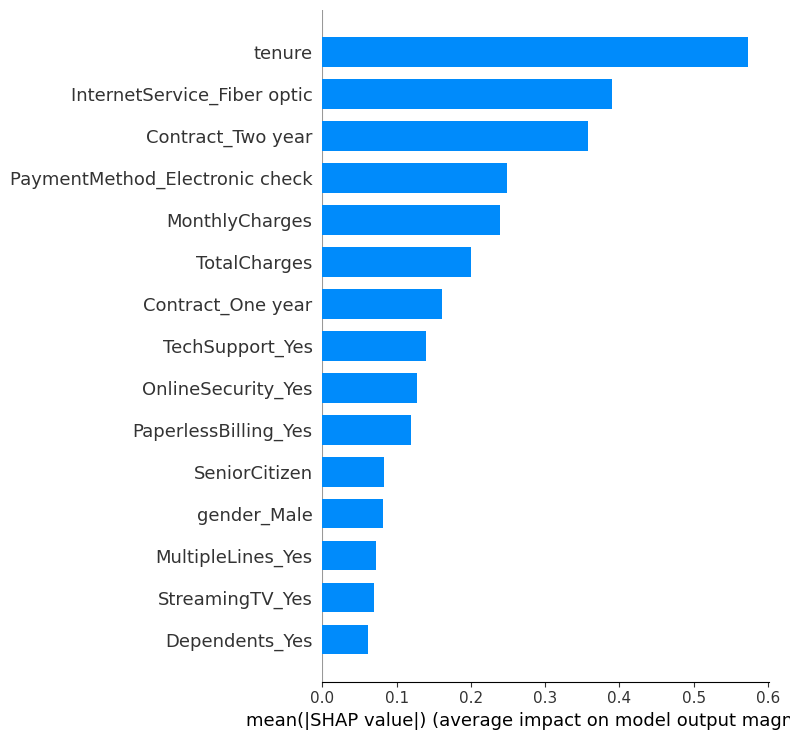

Saved SHAP summary plot.


In [12]:
# Feature importance for the best CatBoost model
# Uses CatBoost's built-in importance (fast). If `shap` is installed,
# also produce a SHAP summary bar plot for the same model.
import numpy as np

cat_importance = pd.Series(
    best_cat.get_feature_importance(),
    index=X_train.columns,
).sort_values(ascending=True)

top = cat_importance.tail(15)
fig, ax = plt.subplots(figsize=(7, 6))
top.plot(kind="barh", ax=ax, color="#55A868")
ax.set_xlabel("CatBoost feature importance")
ax.set_title("Top 15 churn drivers — CatBoost")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/feature_importance_catboost.png", dpi=150, bbox_inches="tight")
plt.show()

cat_importance.sort_values(ascending=False).to_csv(
    f"{FIG_DIR}/feature_importance_catboost.csv", header=["importance"]
)
print(f"Saved -> {FIG_DIR}/feature_importance_catboost.csv")

try:
    import shap
    explainer = shap.TreeExplainer(best_cat)
    sv = explainer.shap_values(X_val)
    shap.summary_plot(sv, X_val, plot_type="bar", show=False, max_display=15)
    plt.tight_layout()
    plt.savefig(f"{FIG_DIR}/shap_summary_catboost.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved SHAP summary plot.")
except Exception as e:
    print(f"(Optional) Skipped SHAP plot: {e}")


## Unified comparison across all 4 models

Combines `baseline_metrics.csv` + `nn_metrics.csv` + `boosted_metrics.csv`.
Run the other two notebooks first; rerun this cell.

In [13]:
# Combine baseline + neural network + boosted metrics into a single
# poster-ready table.
import os
files = [
    f"{FIG_DIR}/baseline_metrics.csv",
    f"{FIG_DIR}/nn_metrics.csv",
    f"{FIG_DIR}/boosted_metrics.csv",
]
parts = []
for f in files:
    if os.path.exists(f):
        parts.append(pd.read_csv(f))
    else:
        print(f"[skip] missing: {f}  (run that notebook first)")

if parts:
    all_df = pd.concat(parts, ignore_index=True)
    cols = ["model", "accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]
    keep = [c for c in cols if c in all_df.columns]
    all_df = all_df[keep + [c for c in all_df.columns if c not in keep]]
    all_df = all_df.drop_duplicates(subset=["model"], keep="last").reset_index(drop=True)
    all_df = all_df.sort_values("f1", ascending=False).reset_index(drop=True)
    all_df.to_csv(f"{FIG_DIR}/all_models_comparison.csv", index=False)
    print(f"Saved -> {FIG_DIR}/all_models_comparison.csv")
    display_cols = [c for c in ["model","accuracy","precision","recall","f1","roc_auc","pr_auc"] if c in all_df.columns]
    print(all_df[display_cols].to_string(index=False))


Saved -> figures/all_models_comparison.csv
                         model  accuracy  precision   recall       f1  roc_auc   pr_auc
                      CatBoost  0.758294   0.531486 0.753571 0.623338 0.839924 0.642494
Logistic Regression (baseline)  0.735071   0.501126 0.793226 0.614217 0.837656 0.615804
           Logistic Regression  0.746919   0.516049 0.746429 0.610219 0.831180 0.591030
                           MLP  0.730806   0.495370 0.764286 0.601124 0.825263 0.594987
                       XGBoost  0.691943   0.457627 0.867857 0.599260 0.836871 0.638909


Saved -> figures/test_predictions.csv
Brier Logistic Regression: 0.1763
Brier CatBoost: 0.1392
Brier XGBoost: 0.1684
Brier MLP: 0.1796

Calibration target: CatBoost


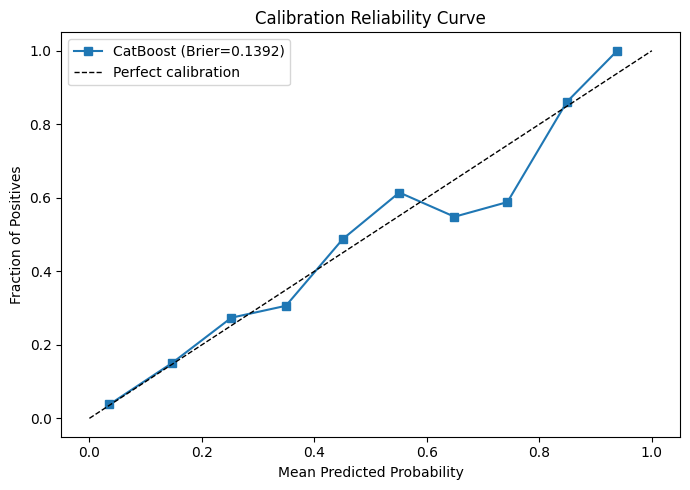

Saved -> figures/calibration_reliability.png
Updated Brier -> figures/all_models_comparison.csv
                         model   pr_auc    brier
                      CatBoost 0.642494 0.139161
Logistic Regression (baseline) 0.615804      NaN
           Logistic Regression 0.591030 0.176339
                           MLP 0.594987 0.179569
                       XGBoost 0.638909 0.168372


In [14]:
from sklearn.metrics import brier_score_loss
from sklearn.calibration import calibration_curve

# Save raw test probabilities for business_evaluation.py
pd.DataFrame({
    'y_true': y_test.to_numpy(),
    'lr_proba': p_test_lr,
    'catboost_proba': p_test_cat,
    'xgboost_proba': p_test_xgb,
}).to_csv(f"{FIG_DIR}/test_predictions.csv", index=False)
print(f"Saved -> {FIG_DIR}/test_predictions.csv")

# Brier scores for models available in this notebook
_yt = y_test.to_numpy()
brier_scores = {
    'Logistic Regression': brier_score_loss(_yt, p_test_lr),
    'CatBoost': brier_score_loss(_yt, p_test_cat),
    'XGBoost': brier_score_loss(_yt, p_test_xgb),
}
_nn_pp = f"{FIG_DIR}/nn_test_predictions.csv"
if os.path.exists(_nn_pp):
    _nn_pdf = pd.read_csv(_nn_pp)
    brier_scores['MLP'] = brier_score_loss(_nn_pdf['y_true'].values, _nn_pdf['mlp_proba'].values)
for _nm, _bs in brier_scores.items():
    print(f"Brier {_nm}: {_bs:.4f}")

# Pick best model available here by PR-AUC from all_models_comparison.csv
_avail = {'Logistic Regression': p_test_lr, 'CatBoost': p_test_cat, 'XGBoost': p_test_xgb}
_comp_path = f"{FIG_DIR}/all_models_comparison.csv"
if os.path.exists(_comp_path):
    _comp = pd.read_csv(_comp_path)
    _pr_col = next(c for c in _comp.columns if 'pr' in c.lower() and 'auc' in c.lower())
    calib_model_name = (
        _comp[_comp['model'].isin(_avail)].sort_values(_pr_col, ascending=False).iloc[0]['model']
    )
else:
    calib_model_name = 'XGBoost'

calib_proba = _avail[calib_model_name]
print(f"\nCalibration target: {calib_model_name}")

# Reliability curve
calib_frac_pos, calib_mean_pred = calibration_curve(_yt, calib_proba, n_bins=10)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(calib_mean_pred, calib_frac_pos, 's-',
        label=f"{calib_model_name} (Brier={brier_scores.get(calib_model_name, float('nan')):.4f})")
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Perfect calibration')
ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction of Positives')
ax.set_title('Calibration Reliability Curve')
ax.legend()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/calibration_reliability.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved -> {FIG_DIR}/calibration_reliability.png")

# Append Brier column to all_models_comparison.csv
if os.path.exists(_comp_path):
    _comp = pd.read_csv(_comp_path)
    _comp['brier'] = _comp['model'].map(brier_scores)
    _comp.to_csv(_comp_path, index=False)
    _show = [c for c in ['model', 'pr_auc', 'brier'] if c in _comp.columns]
    print(f"Updated Brier -> {_comp_path}")
    print(_comp[_show].to_string(index=False))


Max calibration gap: 0.1549
Miscalibration detected — fitting isotonic recalibration on validation set.
Brier after isotonic: 0.1412  (was 0.1392)


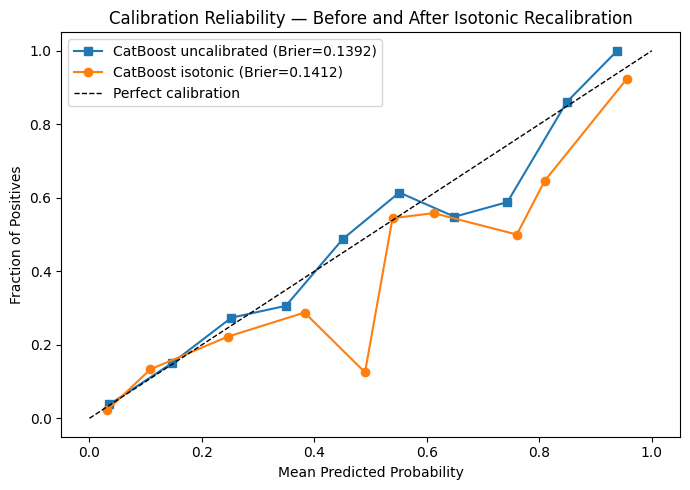

Updated -> figures/calibration_reliability.png


In [15]:
from sklearn.isotonic import IsotonicRegression

_max_gap = float(np.max(np.abs(calib_frac_pos - calib_mean_pred)))
print(f"Max calibration gap: {_max_gap:.4f}")

if _max_gap > 0.02:
    print("Miscalibration detected — fitting isotonic recalibration on validation set.")
    # Map calib_model_name to its validation probabilities (already computed during training)
    _p_val_map = {
        'Logistic Regression': p_val_lr,
        'CatBoost': p_val_cat,
        'XGBoost': p_val_xgb,
    }
    _p_val_best = _p_val_map[calib_model_name]

    _ir = IsotonicRegression(out_of_bounds='clip')
    _ir.fit(_p_val_best, y_val.to_numpy())
    _p_cal = _ir.predict(calib_proba)

    _brier_cal = brier_score_loss(y_test.to_numpy(), _p_cal)
    _frac_cal, _mean_cal = calibration_curve(y_test.to_numpy(), _p_cal, n_bins=10)
    print(f"Brier after isotonic: {_brier_cal:.4f}  (was {brier_scores.get(calib_model_name, float('nan')):.4f})")

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(calib_mean_pred, calib_frac_pos, 's-',
            label=f"{calib_model_name} uncalibrated (Brier={brier_scores.get(calib_model_name, float('nan')):.4f})")
    ax.plot(_mean_cal, _frac_cal, 'o-',
            label=f"{calib_model_name} isotonic (Brier={_brier_cal:.4f})")
    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Perfect calibration')
    ax.set_xlabel('Mean Predicted Probability')
    ax.set_ylabel('Fraction of Positives')
    ax.set_title('Calibration Reliability — Before and After Isotonic Recalibration')
    ax.legend()
    plt.tight_layout()
    plt.savefig(f"{FIG_DIR}/calibration_reliability.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Updated -> {FIG_DIR}/calibration_reliability.png")
else:
    print(f"Calibration acceptable (max gap {_max_gap:.4f} \u2264 0.02); no isotonic recalibration needed.")


Target: X_test row 1032, label=3380, prob=0.9384


Best perturbation: Contract  'Month-to-month' -> 'One year'  drop=0.1324
Saved -> figures/counterfactual_example.csv


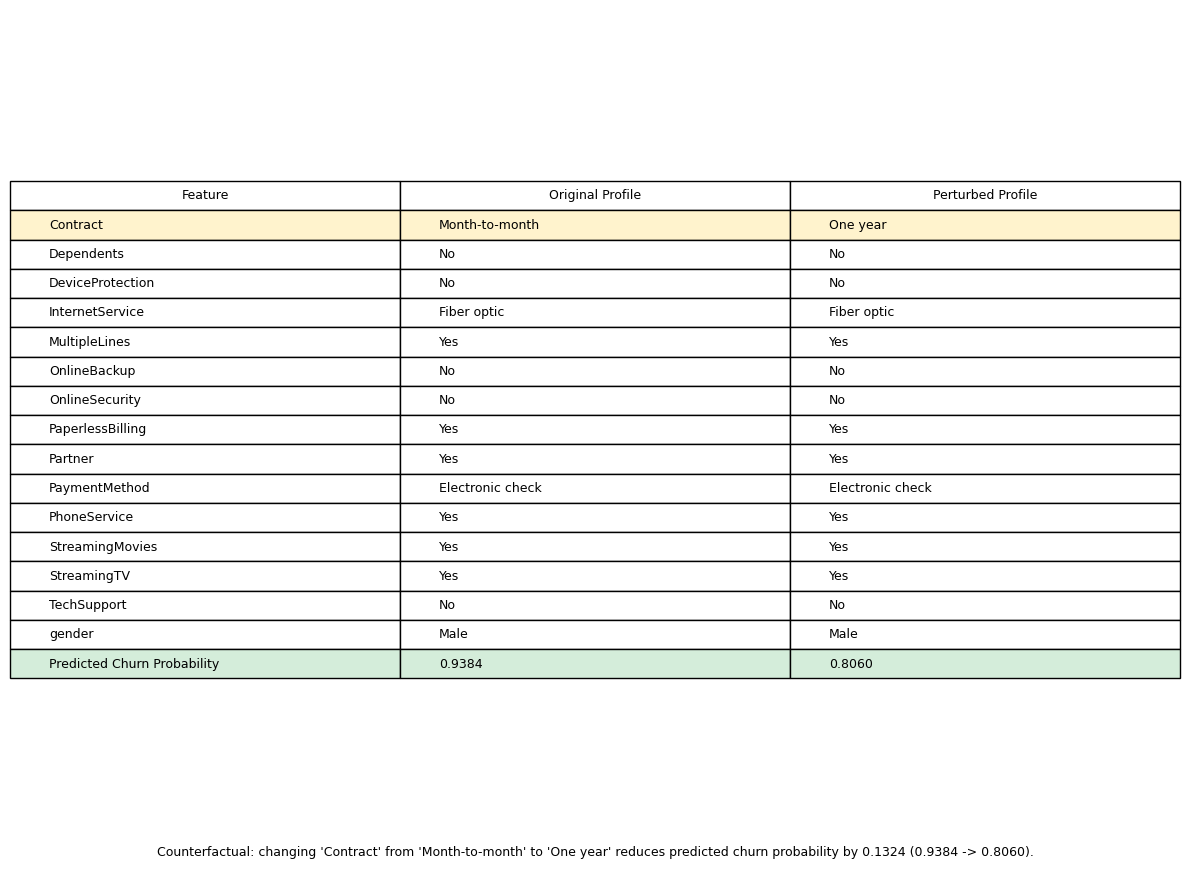

Saved -> figures/counterfactual_example.png


In [16]:
# Find test-set customer with highest CatBoost churn probability who actually churned
_yt_arr = y_test.to_numpy()
_churner_idx = int(np.argmax(np.where(_yt_arr == 1, p_test_cat, -1.0)))
_orig_prob   = float(p_test_cat[_churner_idx])
print(f"Target: X_test row {_churner_idx}, label={X_test.index[_churner_idx]}, prob={_orig_prob:.4f}")

# Identify one-hot encoded feature groups (columns with underscore separating feature from value)
_ind_cols = [c for c in X_test.columns if '_' in c]
_feat_groups = {}
for _c in _ind_cols:
    _feat_groups.setdefault(_c.split('_', 1)[0], []).append(_c)

# Derive baseline (dropped) value name for each feature from the original dataframe
_baseline_vals = {}
for _f, _fc in _feat_groups.items():
    _encoded = {_c.split('_', 1)[1] for _c in _fc}
    _all_vals = [str(v) for v in df[_f].unique()]
    _base = next((v for v in _all_vals if v not in _encoded), '[baseline]')
    _baseline_vals[_f] = _base

# Enumerate lowest-risk perturbation per categorical feature
_cust_cols = X_test.columns.tolist()
_cust_arr  = X_test.iloc[_churner_idx].values.astype(float).copy()
_col_idx   = {c: i for i, c in enumerate(_cust_cols)}

def _state_name(state, fcols, bval):
    return bval if state.sum() == 0 else fcols[int(np.argmax(state))].split('_', 1)[1]

def _predict(arr):
    return float(best_cat.predict_proba(
        pd.DataFrame([arr], columns=_cust_cols))[0, 1])

_perturbations = []
for _f, _fc in sorted(_feat_groups.items()):
    _n = len(_fc)
    _cur = np.array([_cust_arr[_col_idx[c]] for c in _fc])
    _cur_name = _state_name(_cur, _fc, _baseline_vals[_f])

    _states = [np.zeros(_n)] + [np.eye(_n)[i] for i in range(_n)]
    _names  = [_baseline_vals[_f]] + [_fc[i].split('_', 1)[1] for i in range(_n)]

    _best_prob, _best_name = _orig_prob, _cur_name
    for _st, _nm in zip(_states, _names):
        if _nm == _cur_name:
            continue
        _mod = _cust_arr.copy()
        for _ci, _c in enumerate(_fc):
            _mod[_col_idx[_c]] = _st[_ci]
        _p = _predict(_mod)
        if _p < _best_prob:
            _best_prob, _best_name = _p, _nm

    _perturbations.append({
        'feature': _f, 'original_value': _cur_name, 'best_value': _best_name,
        'perturbed_prob': _best_prob, 'prob_drop': _orig_prob - _best_prob,
    })

# Single best perturbation (largest probability drop)
_perturbations.sort(key=lambda x: x['prob_drop'], reverse=True)
_bp = _perturbations[0]
print(f"Best perturbation: {_bp['feature']}  "
      f"'{_bp['original_value']}' -> '{_bp['best_value']}'  "
      f"drop={_bp['prob_drop']:.4f}")

# Apply best perturbation
_pert_arr = _cust_arr.copy()
_pf, _pfc = _bp['feature'], _feat_groups[_bp['feature']]
if _bp['best_value'] == _baseline_vals[_pf]:
    for _c in _pfc:
        _pert_arr[_col_idx[_c]] = 0.0
else:
    for _c in _pfc:
        _pert_arr[_col_idx[_c]] = 1.0 if _c.split('_', 1)[1] == _bp['best_value'] else 0.0
_pert_prob = _predict(_pert_arr)

# Build table rows: categorical features + probability row
_rows = []
for _f, _fc in sorted(_feat_groups.items()):
    _cur = np.array([_cust_arr[_col_idx[c]] for c in _fc])
    _prt = np.array([_pert_arr[_col_idx[c]] for c in _fc])
    _rows.append((_f, _state_name(_cur, _fc, _baseline_vals[_f]),
                       _state_name(_prt, _fc, _baseline_vals[_f])))
_rows.append(('Predicted Churn Probability', f"{_orig_prob:.4f}", f"{_pert_prob:.4f}"))

# Save CSV
pd.DataFrame([{'feature': r[0], 'original_value': r[1], 'perturbed_value': r[2]}
              for r in _rows]).to_csv(f"{FIG_DIR}/counterfactual_example.csv", index=False)
print(f"Saved -> {FIG_DIR}/counterfactual_example.csv")

# Figure: two-column table
_fig, _ax = plt.subplots(figsize=(12, max(7, len(_rows) * 0.45 + 1.5)))
_ax.axis('off')
_tbl = _ax.table(
    cellText=[list(r) for r in _rows],
    colLabels=['Feature', 'Original Profile', 'Perturbed Profile'],
    loc='center', cellLoc='left',
)
_tbl.auto_set_font_size(False)
_tbl.set_fontsize(9)
_tbl.scale(1, 1.4)

_changed = next((i for i, r in enumerate(_rows[:-1]) if r[1] != r[2]), None)
if _changed is not None:
    for _ci in range(3):
        _tbl[_changed + 1, _ci].set_facecolor('#FFF3CD')
for _ci in range(3):
    _tbl[len(_rows), _ci].set_facecolor('#D4EDDA')

_caption = (
    f"Counterfactual: changing '{_bp['feature']}' from '{_bp['original_value']}' "
    f"to '{_bp['best_value']}' reduces predicted churn probability by "
    f"{_bp['prob_drop']:.4f} ({_orig_prob:.4f} -> {_pert_prob:.4f})."
)
_fig.text(0.5, 0.01, _caption, ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/counterfactual_example.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved -> {FIG_DIR}/counterfactual_example.png")
